# EDA — Dataset Scoring Épargne (`final.csv`)

Notebook d'exploration visuelle du dataset final (post feature engineering) : 4005 lignes, 45 colonnes.

**Objectif** : comprendre chaque colonne, sa distribution, et les relations entre colonnes (y compris avec la variable cible `label_nom` / `label_code`).

**Plan** :
1. Chargement & aperçu général
2. Qualité des données (valeurs manquantes, doublons, cardinalité)
3. Variable cible
4. Distribution des variables numériques
5. Distribution des variables catégorielles
6. Colonnes indicatrices / flags binaires
7. Corrélations entre variables numériques
8. Relations variables numériques ↔ cible
9. Relations variables catégorielles ↔ cible
10. Synthèse


## 1. Setup & chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)

DATA_PATH = "final.csv"  # adapter le chemin si besoin
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(4005, 41)


,CODE_VILLE,BPR,GENDER,MARITAL_STATUS,NOMBRE_ENFANT,CUSTOMER_RATING,TAILLE_ENTREPRI,age_client,label_code,label_nom,pack_actuel,pack_etat,solde_moyen,solde_min,nb_mois_observes_solde,depot_moyen,flux_cred_total,nb_mois_avec_flux,nb_operations_gab,montant_total_gab,montant_moyen_gab,nb_retraits,montant_total_retraits,nb_paiements_digitaux,montant_total_payfac,nb_vignettes_payees,montant_total_vignette,jamais_active_digital,jamais_utilise_gab,anciennete_digitale_jours_imp,recence_gab_jours_imp,nb_mois_observes_solde_etait_extreme,solde_moyen_etait_extreme,solde_min_etait_extreme,solde_max_etait_extreme,depot_moyen_etait_extreme,flux_cred_moyen_etait_extreme,flux_cred_total_etait_extreme,montant_total_retraits_etait_extreme,solde_volatilite_indefinie,solde_volatilite_relative_imp
0,101,45,M,9,0,SVC,PARTICULIER,28,9,MaRetraite,PLOC1,W,-709.570000,-1204.57,24,0.000000,0.00,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,1,3170,687,0,0,0,0,0,0,0,0,1,3.550722
1,780,78,M,1,0,SVC,PARTICULIER,31,9,MaRetraite,PLOC1,W,-2285.043220,-3844.43,36,0.000000,0.00,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,1,1,4002,687,1,0,1,0,0,0,0,0,1,3.550722
2,780,78,M,1,0,SVC,PARTICULIER,32,9,MaRetraite,PLOCI,W,-2155.240000,-2772.99,24,0.000000,0.00,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,1,4148,687,0,0,0,0,0,0,0,0,1,3.550722
3,780,78,M,1,0,SVC,PARTICULIER,53,9,MaRetraite,PLOCI,W,-688.235417,-1085.50,24,0.000000,0.00,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,1,1,4002,687,0,0,0,0,0,0,0,0,1,3.550722
4,780,78,M,1,0,SVC,PARTICULIER,35,9,MaRetraite,PLOCI,W,209.811875,-10.43,36,314.165238,8443.65,8,2,0.0,0.0,1,100.0,0,0.0,0,0.0,1,0,4002,654,1,0,0,0,0,0,0,0,0,6.973914


In [2]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODE_VILLE,4005,272,780,712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BPR,4005.0,NaN,NaN,NaN,52.080649,25.428088,1.0,27.0,50.0,78.0,81.0
GENDER,4005,2,M,2567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MARITAL_STATUS,4005.0,NaN,NaN,NaN,2.844944,2.356083,1.0,1.0,3.0,3.0,9.0
NOMBRE_ENFANT,4005.0,NaN,NaN,NaN,0.743321,1.205231,0.0,0.0,0.0,1.0,12.0
CUSTOMER_RATING,4005,10,SVC,1296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TAILLE_ENTREPRI,4005,2,PARTICULIER,4003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_client,4005.0,NaN,NaN,NaN,44.492634,10.547962,18.0,37.0,43.0,52.0,69.0
label_code,4005.0,NaN,NaN,NaN,17.133084,16.412195,9.0,9.0,9.0,9.0,53.0
label_nom,4005,3,MaRetraite,3038,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Qualité des données

Valeurs manquantes, doublons, cardinalité de chaque colonne.

In [3]:
n_dupes = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_dupes}")


Nombre de lignes dupliquées : 0


In [4]:
cardinality = df.nunique().sort_values(ascending=False)
cardinality.to_frame("n_valeurs_uniques")


,n_valeurs_uniques
solde_moyen,3426
depot_moyen,2809
solde_volatilite_relative_imp,2808
flux_cred_total,2645
solde_min,2426
anciennete_digitale_jours_imp,1976
montant_total_payfac,1102
montant_total_retraits,1082
recence_gab_jours_imp,449
montant_moyen_gab,301


## 3. Variable cible

`label_nom` (et son encodage `label_code`) représente le produit d'épargne — c'est la cible de prédiction.

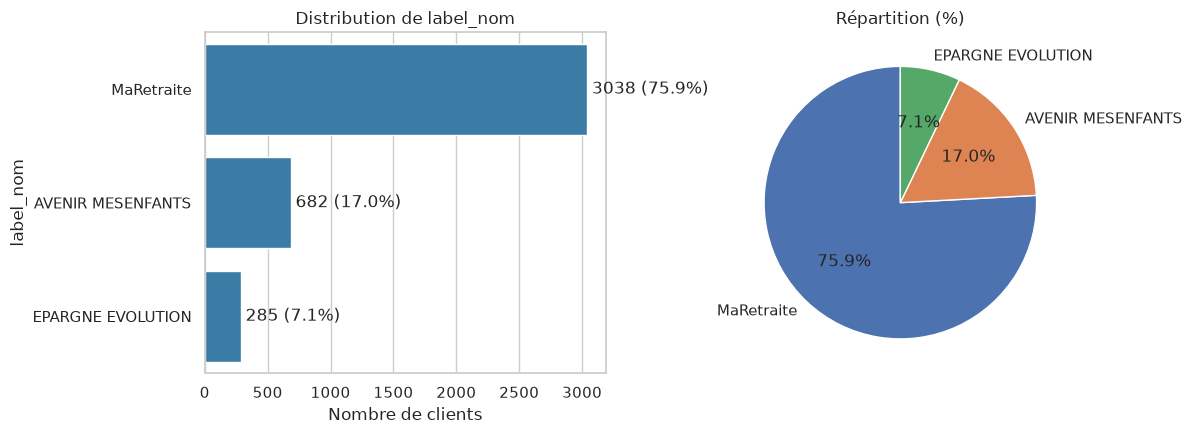

Déséquilibre des classes — à garder en tête pour la modélisation.


In [5]:
target_counts = df["label_nom"].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], color="#2980b9")
axes[0].set_xlabel("Nombre de clients")
axes[0].set_title("Distribution de label_nom")
for i, v in enumerate(target_counts.values):
    axes[0].text(v, i, f" {v} ({target_pct.iloc[i]}%)", va="center")

axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep"))
axes[1].set_title("Répartition (%)")
plt.tight_layout()
plt.show()

print("Déséquilibre des classes — à garder en tête pour la modélisation.")


## 4. Distribution des variables numériques

On sépare les variables numériques "continues/comptages" des colonnes indicatrices binaires (`*_etait_extreme`, `jamais_*`), traitées séparément en section 6.

In [6]:
all_num_cols = df.select_dtypes(include="number").columns.tolist()

flag_cols = [c for c in all_num_cols if c.endswith("_etait_extreme") or c.startswith("jamais_")]
target_like = ["label_code"]
real_num_cols = [c for c in all_num_cols if c not in flag_cols and c not in target_like]

print(f"Variables numériques 'continues' : {len(real_num_cols)}")
print(real_num_cols)
print()
print(f"Colonnes indicatrices binaires : {len(flag_cols)}")
print(flag_cols)


Variables numériques 'continues' : 23
['BPR', 'MARITAL_STATUS', 'NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']

Colonnes indicatrices binaires : 10
['jamais_active_digital', 'jamais_utilise_gab', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme']


In [7]:
df[real_num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
BPR,4005.0,52.080649,25.428088,1.000000,27.00000,50.000000,78.000000,81.000000
MARITAL_STATUS,4005.0,2.844944,2.356083,1.000000,1.00000,3.000000,3.000000,9.000000
NOMBRE_ENFANT,4005.0,0.743321,1.205231,0.000000,0.00000,0.000000,1.000000,12.000000
age_client,4005.0,44.492634,10.547962,18.000000,37.00000,43.000000,52.000000,69.000000
solde_moyen,4005.0,20183.923619,27880.803442,-45401.165833,156.55000,6145.920417,32564.953333,76194.400833
solde_min,4005.0,133.277336,2372.550801,-3844.430000,-971.05000,0.000000,1177.000000,3927.650000
nb_mois_observes_solde,4005.0,25.422222,5.573436,1.000000,24.00000,24.000000,24.000000,36.000000
depot_moyen,4005.0,42274.005096,56783.332020,0.000000,789.98000,11201.833333,66874.869610,155729.800000
flux_cred_total,4005.0,184986.068559,219352.652284,0.000000,8277.50000,90283.000000,277052.890000,647535.900000
nb_mois_avec_flux,4005.0,8.984020,5.888130,0.000000,2.00000,13.000000,13.000000,32.000000


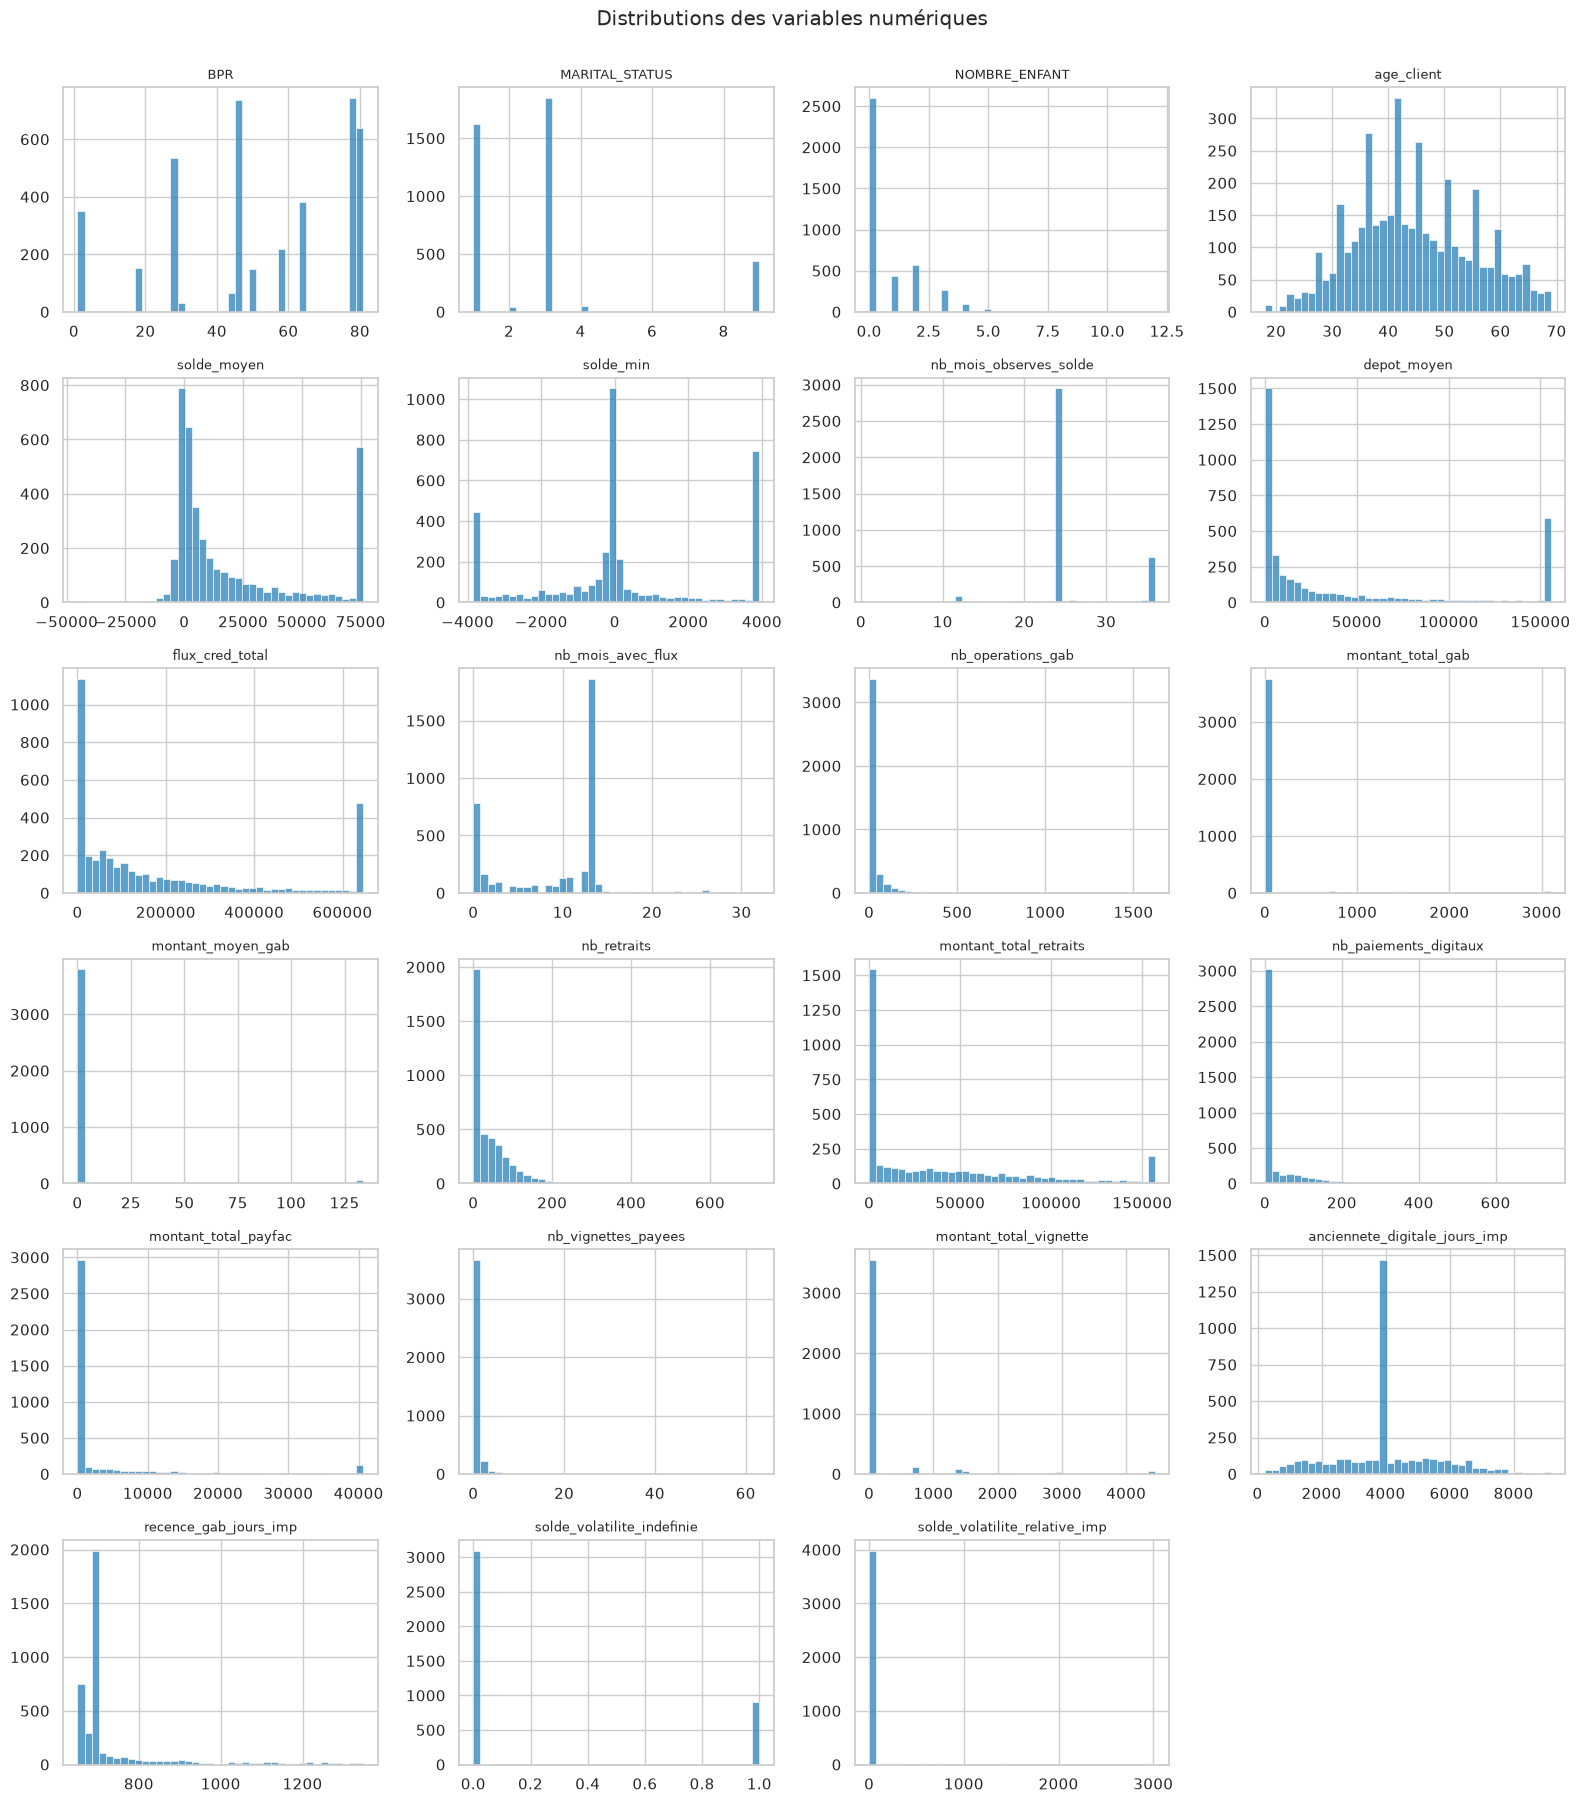

In [8]:
# Histogrammes de toutes les variables numériques "continues"
n = len(real_num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="#2980b9", kde=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions des variables numériques", y=1.001)
plt.tight_layout()
plt.show()


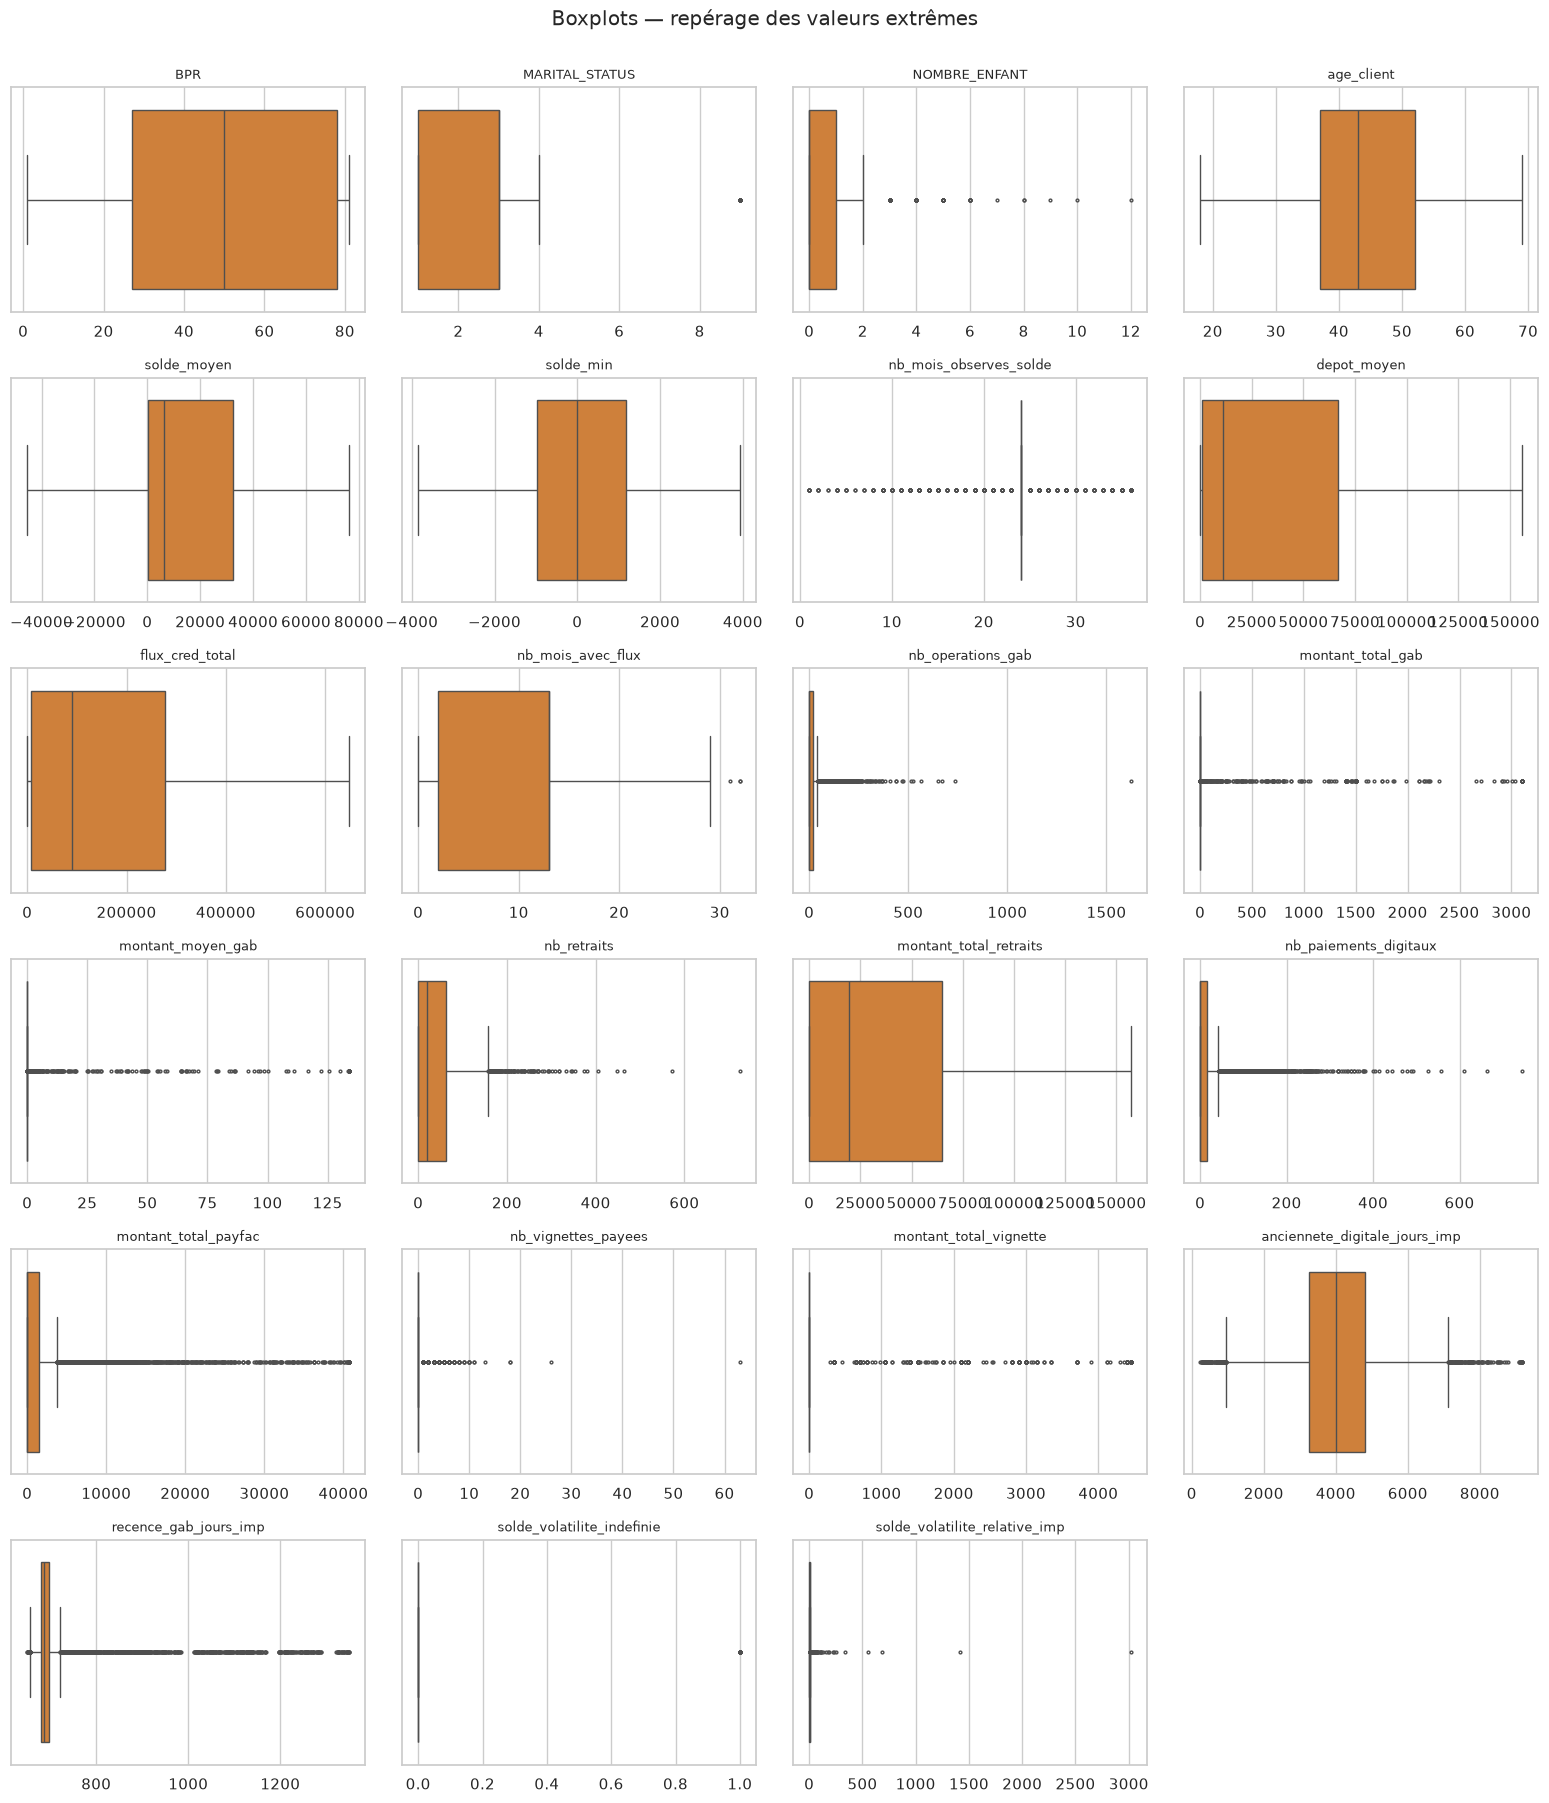

In [9]:
# Boxplots pour repérer visuellement les outliers
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.boxplot(x=df[col].dropna(), ax=ax, color="#e67e22", fliersize=2)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — repérage des valeurs extrêmes", y=1.001)
plt.tight_layout()
plt.show()


In [10]:
# Skewness / asymétrie de chaque variable numérique continue
skew_df = df[real_num_cols].skew().sort_values(ascending=False).to_frame("skewness")
skew_df["interpretation"] = pd.cut(
    skew_df["skewness"].abs(),
    bins=[-0.01, 0.5, 1, np.inf],
    labels=["≈ symétrique", "modérément asymétrique", "fortement asymétrique"]
)
skew_df


,skewness,interpretation
solde_volatilite_relative_imp,44.472864,fortement asymétrique
nb_vignettes_payees,18.927157,fortement asymétrique
nb_operations_gab,8.302819,fortement asymétrique
montant_total_gab,6.423438,fortement asymétrique
montant_moyen_gab,6.255699,fortement asymétrique
montant_total_vignette,4.227759,fortement asymétrique
nb_paiements_digitaux,3.631352,fortement asymétrique
montant_total_payfac,2.839866,fortement asymétrique
recence_gab_jours_imp,2.746972,fortement asymétrique
nb_retraits,2.678908,fortement asymétrique


## 5. Distribution des variables catégorielles

Pour les colonnes à forte cardinalité (`CODE_VILLE`, `pack_actuel`), seules les modalités les plus fréquentes sont affichées.

In [11]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "label_nom"]  # déjà traité en section 3
print(cat_cols)


['CODE_VILLE', 'GENDER', 'CUSTOMER_RATING', 'TAILLE_ENTREPRI', 'pack_actuel', 'pack_etat']


/tmp/ipykernel_23450/3033886653.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [12]:
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"{col} : {n_unique} modalités")


CODE_VILLE : 272 modalités
GENDER : 2 modalités
CUSTOMER_RATING : 10 modalités
TAILLE_ENTREPRI : 2 modalités
pack_actuel : 50 modalités
pack_etat : 3 modalités


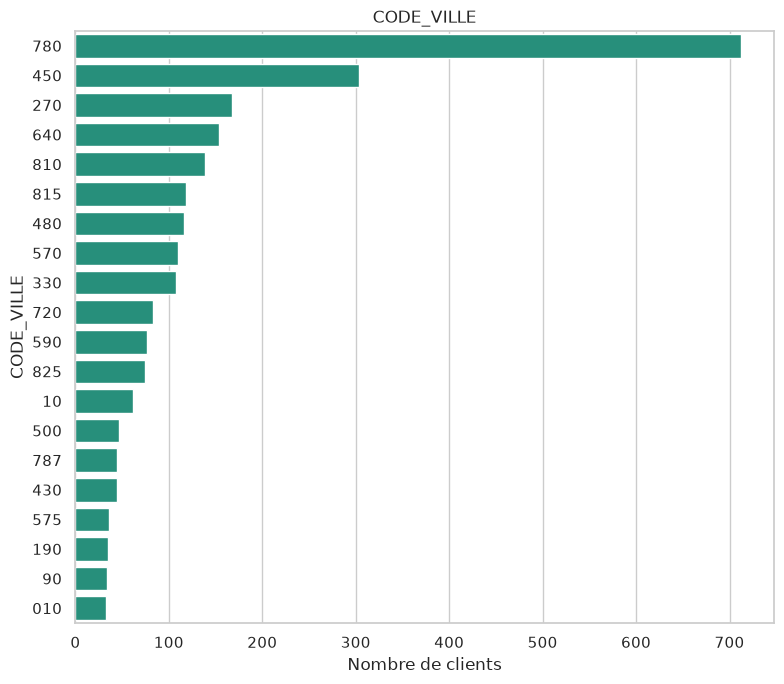

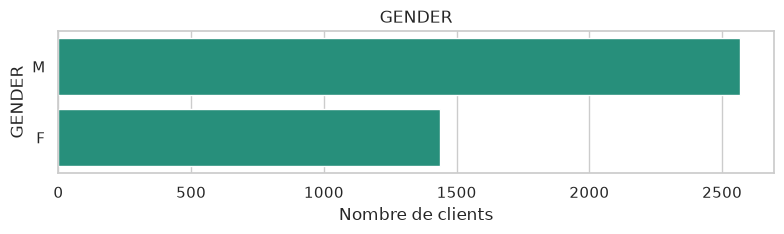

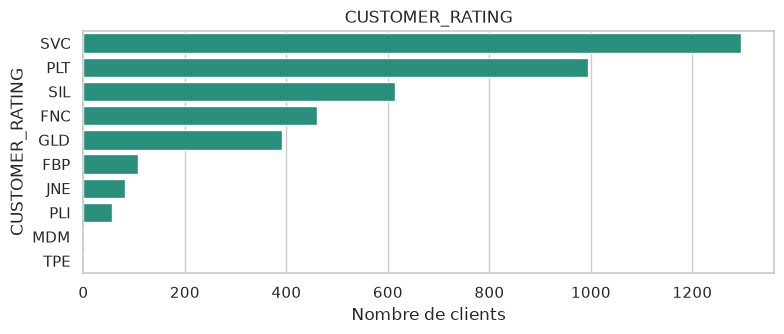

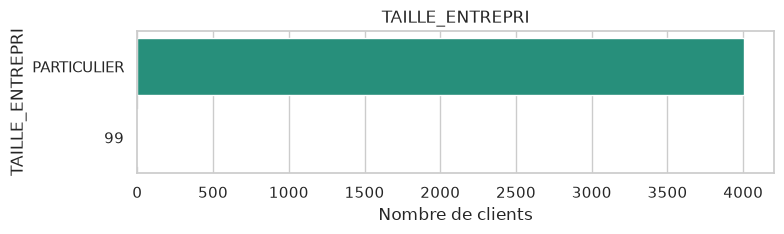

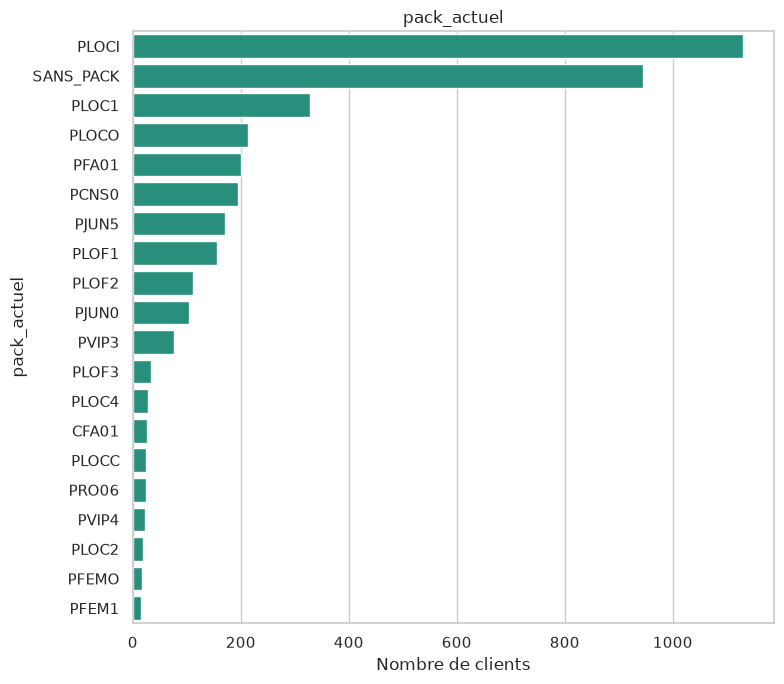

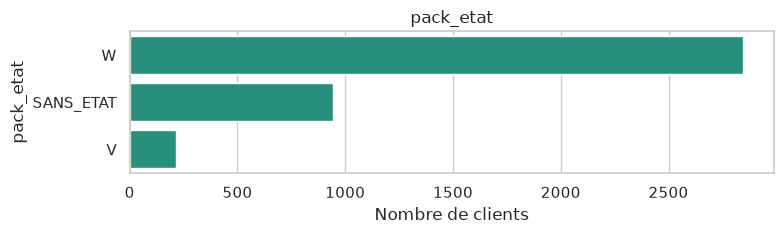

In [13]:
for col in cat_cols:
    counts = df[col].value_counts()
    top = counts.head(20)
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.35*len(top))))
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color="#16a085")
    title = col if n_unique <= 20 else f"{col} (top 20 sur {df[col].nunique()} modalités)"
    ax.set_title(title)
    ax.set_xlabel("Nombre de clients")
    plt.tight_layout()
    plt.show()


## 6. Colonnes indicatrices / flags binaires

Proportion de clients à 1 pour chaque flag (`*_etait_extreme`, `jamais_active_digital`, `jamais_utilise_gab`, ...).

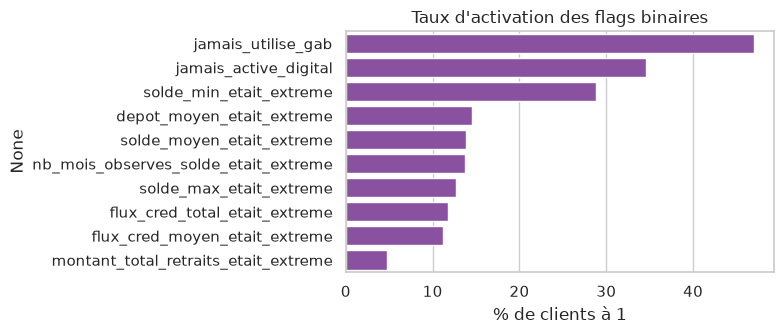

,pct_a_1
jamais_utilise_gab,46.966292
jamais_active_digital,34.556804
solde_min_etait_extreme,28.863920
depot_moyen_etait_extreme,14.506866
solde_moyen_etait_extreme,13.832709
nb_mois_observes_solde_etait_extreme,13.732834
solde_max_etait_extreme,12.684145
flux_cred_total_etait_extreme,11.735331
flux_cred_moyen_etait_extreme,11.161049
montant_total_retraits_etait_extreme,4.694132


In [14]:
flag_rates = (df[flag_cols].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, max(3, 0.35*len(flag_cols))))
sns.barplot(x=flag_rates.values, y=flag_rates.index, ax=ax, color="#8e44ad")
ax.set_xlabel("% de clients à 1")
ax.set_title("Taux d'activation des flags binaires")
plt.tight_layout()
plt.show()

flag_rates.to_frame("pct_a_1")


## 7. Corrélations entre variables numériques

Matrice de corrélation (Pearson) sur les variables numériques continues.

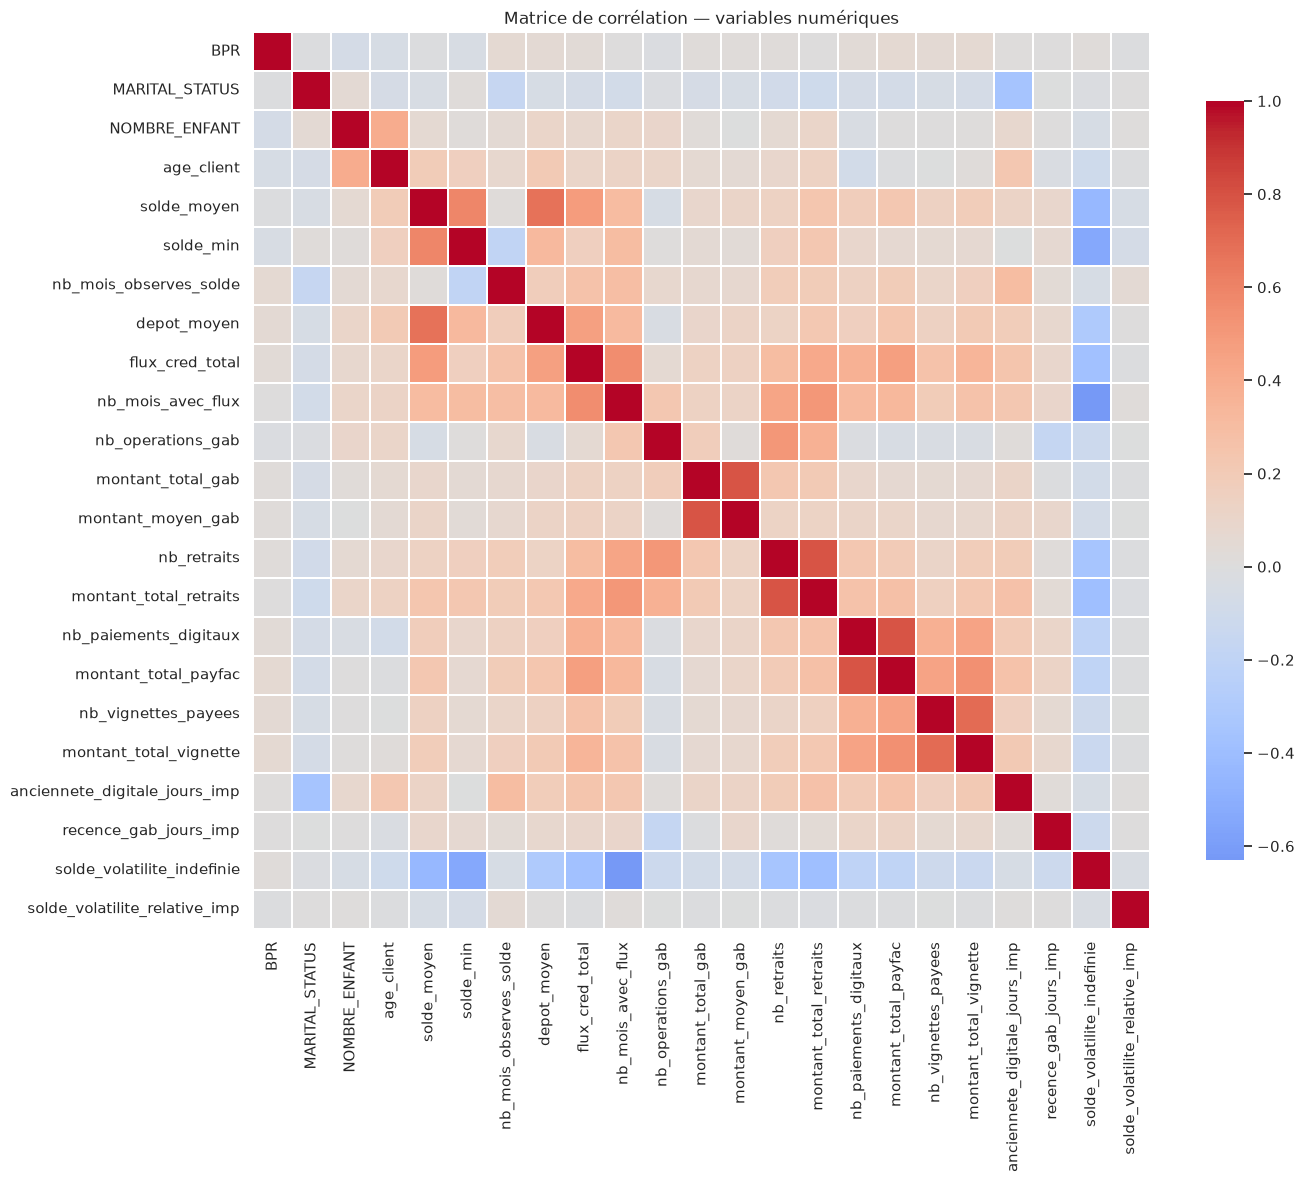

In [15]:
corr = df[real_num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.3)
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()


In [16]:
# Paires de variables les plus corrélées (hors diagonale), en valeur absolue
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(20).drop(columns="abs_corr")


,variable_1,variable_2,correlation
313,nb_retraits,montant_total_retraits,0.793031
361,nb_paiements_digitaux,montant_total_payfac,0.787386
265,montant_total_gab,montant_moyen_gab,0.784046
409,nb_vignettes_payees,montant_total_vignette,0.701828
99,solde_moyen,depot_moyen,0.673384
228,nb_mois_avec_flux,solde_volatilite_indefinie,-0.629923
97,solde_moyen,solde_min,0.587134
193,flux_cred_total,nb_mois_avec_flux,0.555296
386,montant_total_payfac,montant_total_vignette,0.546037
136,solde_min,solde_volatilite_indefinie,-0.545683


In [17]:
# Zoom : paires fortement corrélées (|r| > 0.7)
strong = corr_pairs[corr_pairs["abs_corr"] > 0.7].sort_values("abs_corr", ascending=False)
print(f"{len(strong)} paires avec |corrélation| > 0.7")
strong.drop(columns="abs_corr")


4 paires avec |corrélation| > 0.7


,variable_1,variable_2,correlation
313,nb_retraits,montant_total_retraits,0.793031
361,nb_paiements_digitaux,montant_total_payfac,0.787386
265,montant_total_gab,montant_moyen_gab,0.784046
409,nb_vignettes_payees,montant_total_vignette,0.701828


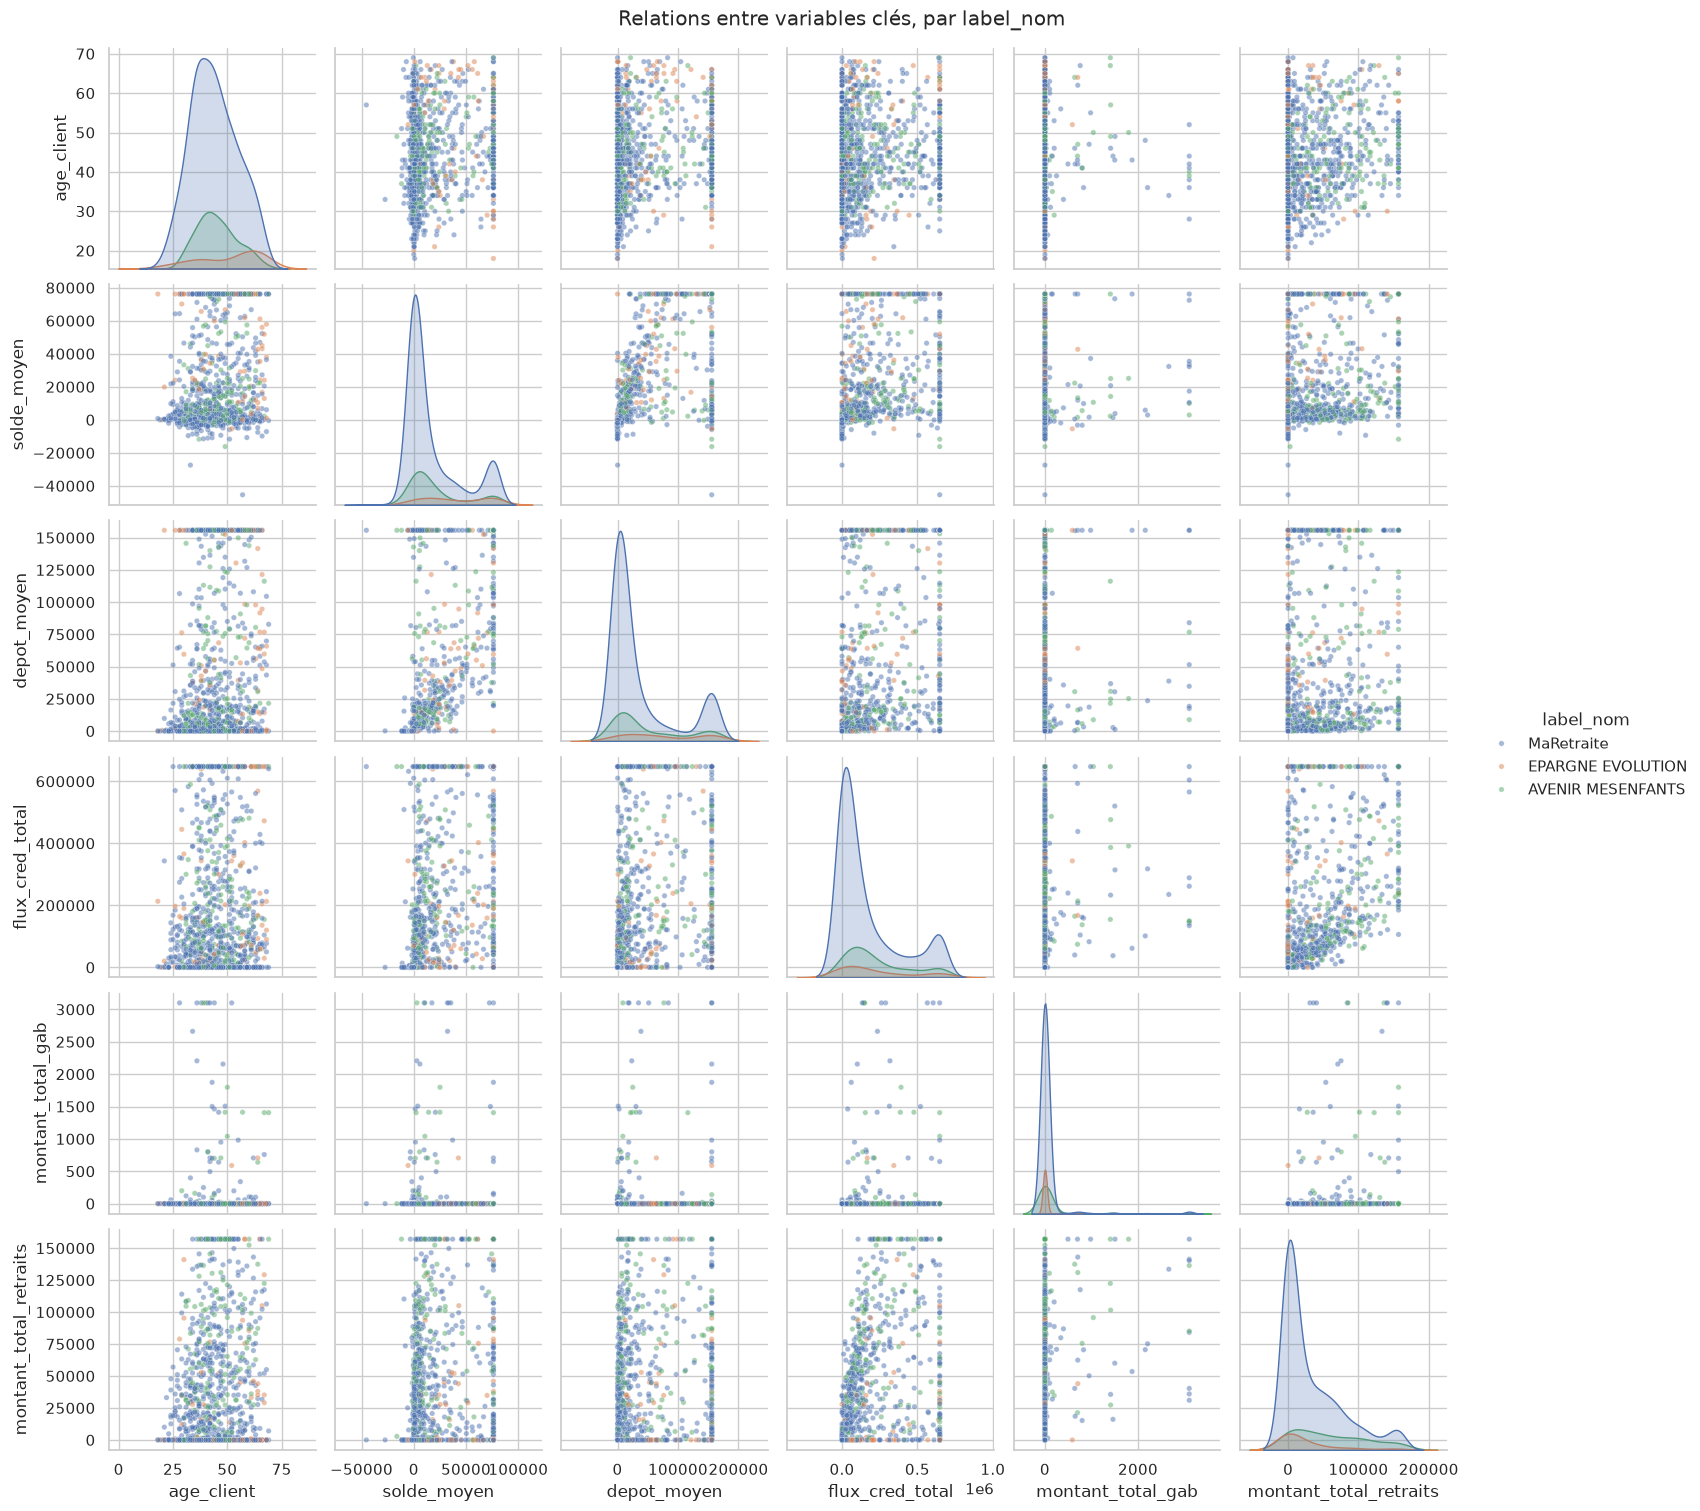

In [18]:
# Pairplot sur un sous-ensemble de variables clés (à adapter selon les besoins)
key_vars = ["age_client", "solde_moyen", "depot_moyen", "flux_cred_total",
            "montant_total_gab", "montant_total_retraits"]
key_vars = [c for c in key_vars if c in df.columns]

sns.pairplot(df[key_vars + ["label_nom"]].sample(min(1000, len(df)), random_state=42),
             hue="label_nom", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Relations entre variables clés, par label_nom", y=1.01)
plt.show()


## 8. Variables numériques vs. cible (`label_nom`)

Boxplots comparant la distribution de chaque variable numérique clé selon la classe cible.

/tmp/ipykernel_23450/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_23450/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_23450/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_23450/1758376510.py:14: FutureWarning: 

Passing `palette` wi

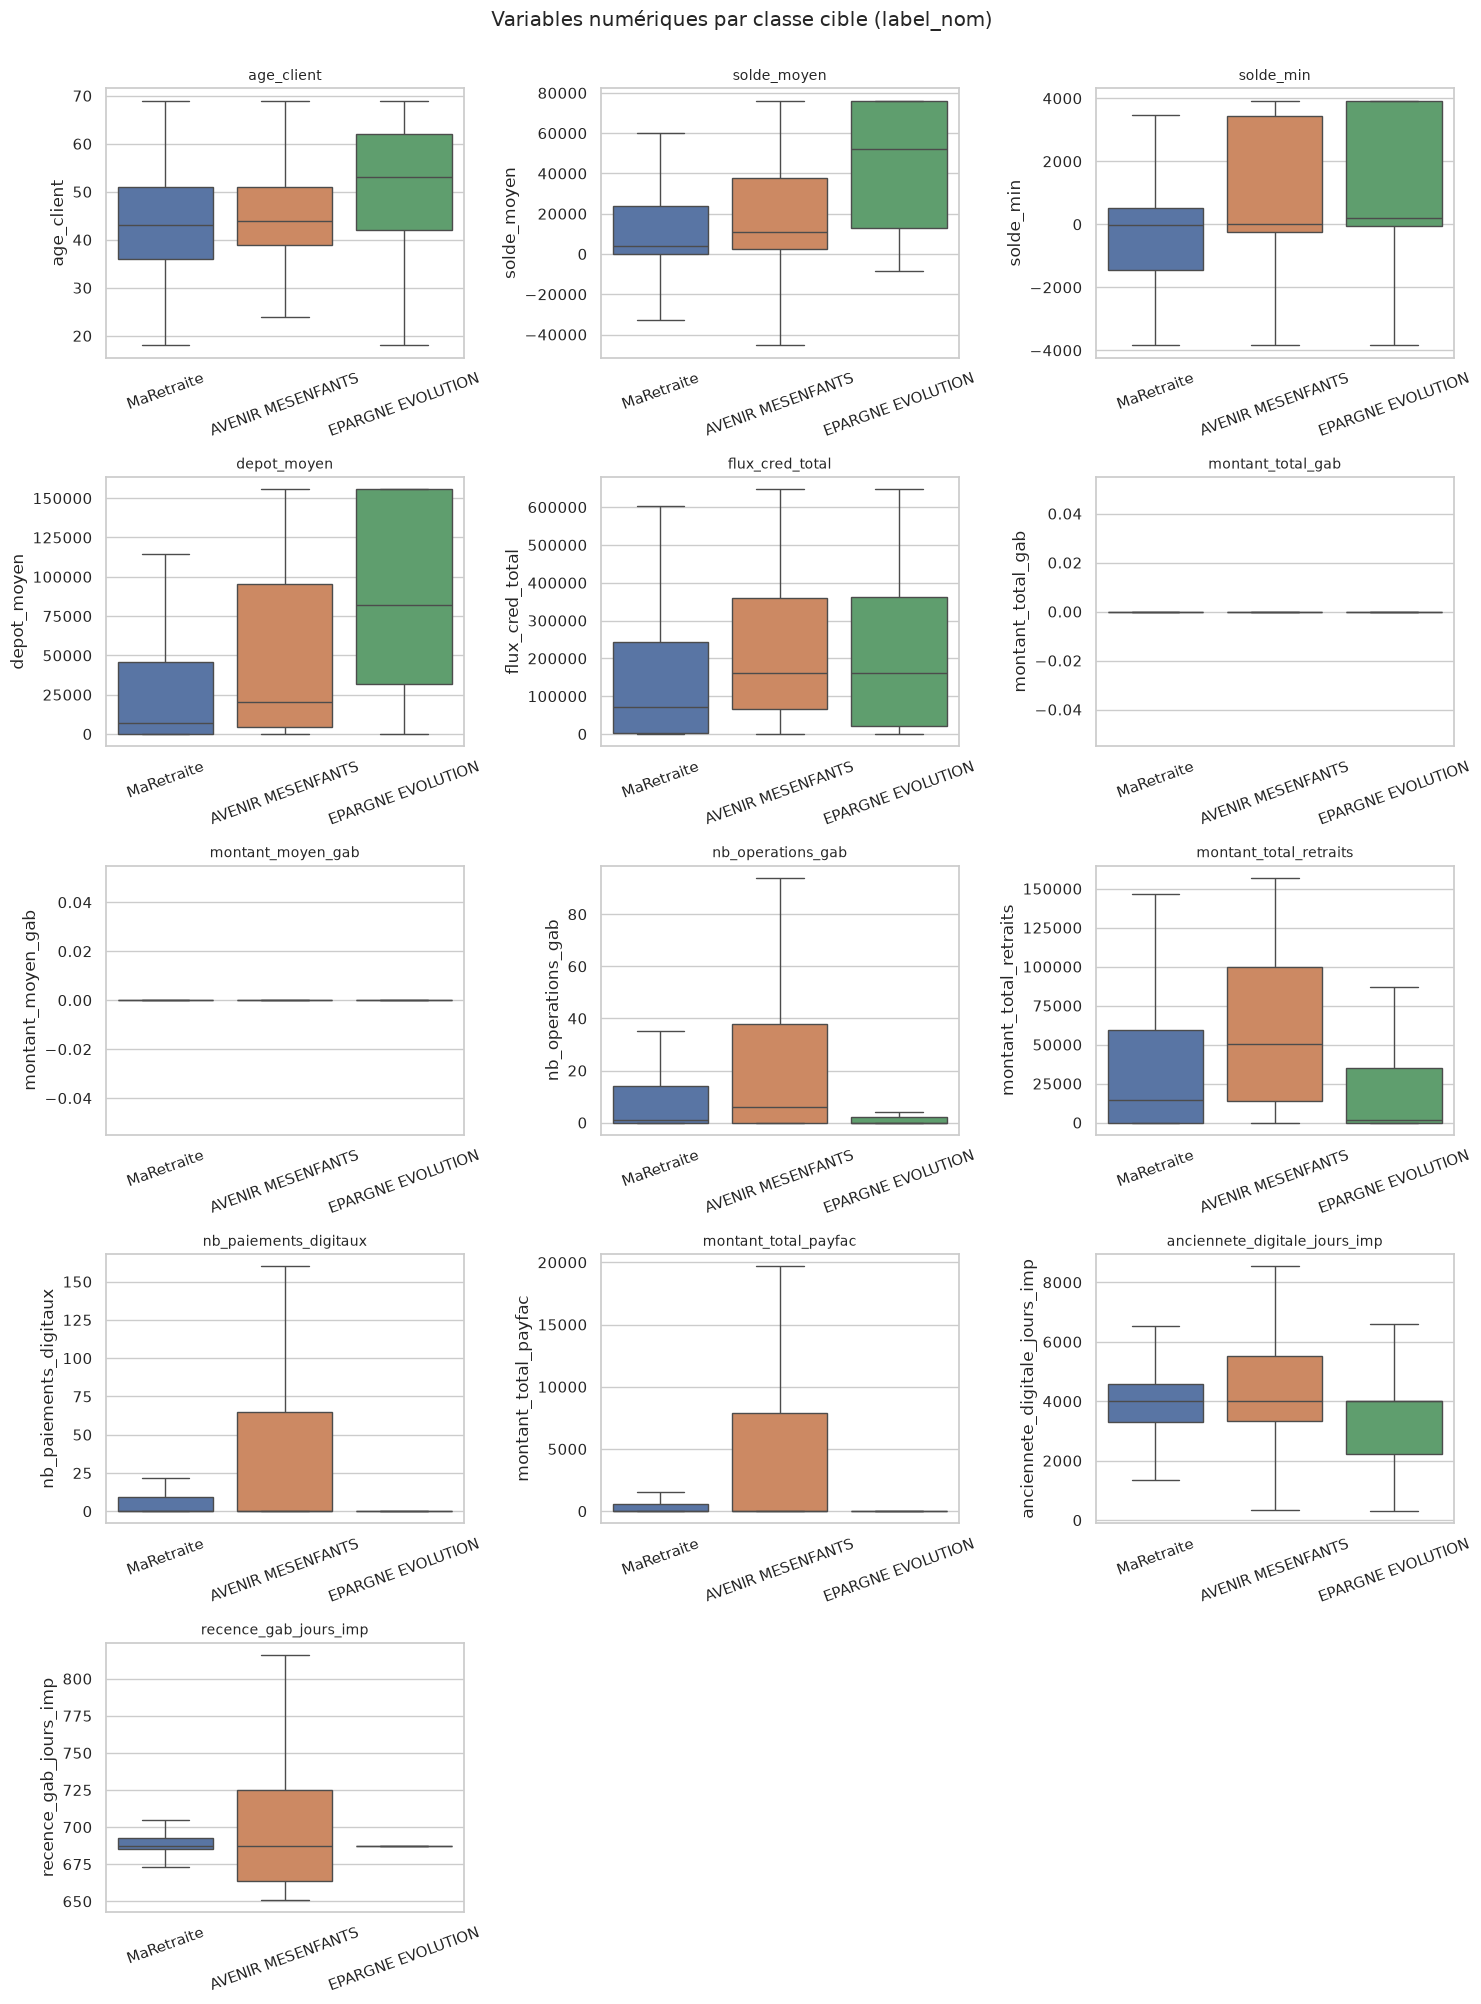

In [19]:
plot_vars = ["age_client", "solde_moyen", "solde_min", "depot_moyen", "flux_cred_total",
             "montant_total_gab", "montant_moyen_gab", "nb_operations_gab",
             "montant_total_retraits", "nb_paiements_digitaux", "montant_total_payfac",
             "anciennete_digitale_jours_imp", "recence_gab_jours_imp", "solde_volatilite_relative"]
plot_vars = [c for c in plot_vars if c in real_num_cols]

ncols = 3
nrows = int(np.ceil(len(plot_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(plot_vars):
    ax = axes[i]
    sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Variables numériques par classe cible (label_nom)", y=1.001)
plt.tight_layout()
plt.show()


In [20]:
# Moyennes par classe cible pour toutes les variables numériques continues
df.groupby("label_nom")[real_num_cols].mean().T


label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite
BPR,53.816716,51.982456,51.700132
MARITAL_STATUS,2.835777,3.214035,2.812377
NOMBRE_ENFANT,0.916422,0.982456,0.682028
age_client,45.200880,51.038596,43.719552
solde_moyen,23501.902097,45282.711994,17084.510844
solde_min,651.214179,1489.022175,-110.178953
nb_mois_observes_solde,26.297654,24.221053,25.338381
depot_moyen,51807.514508,87092.670079,35929.313543
flux_cred_total,236085.969443,231501.806070,169150.940978
nb_mois_avec_flux,11.551320,7.154386,8.579329


## 9. Variables catégorielles vs. cible

Répartition de `label_nom` au sein de chaque modalité (pour les catégorielles à cardinalité raisonnable).

In [21]:
low_card_cats = [c for c in cat_cols if df[c].nunique() <= 15]
print(low_card_cats)


['GENDER', 'CUSTOMER_RATING', 'TAILLE_ENTREPRI', 'pack_etat']


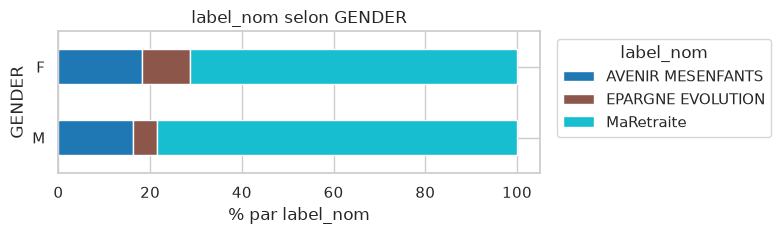

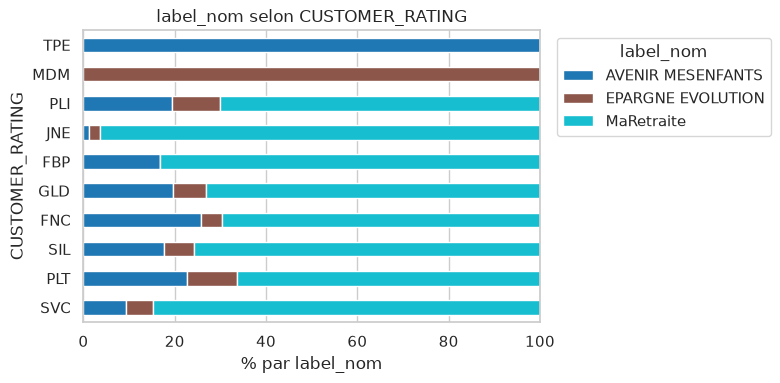

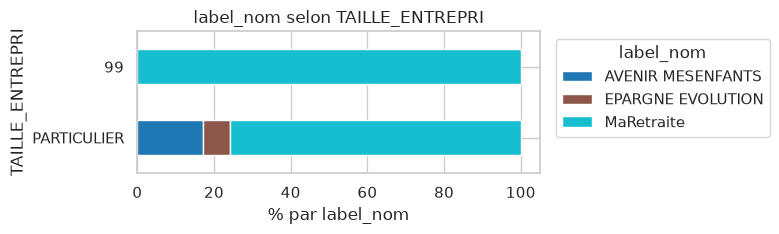

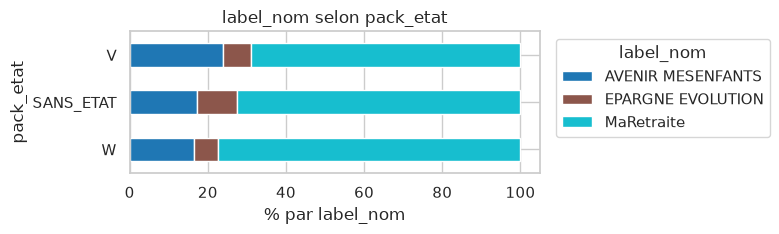

In [22]:
for col in low_card_cats:
    ct = pd.crosstab(df[col], df["label_nom"], normalize="index") * 100
    ct = ct.loc[df[col].value_counts().index]  # trier par fréquence

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.4*len(ct))))
    ct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
    ax.set_xlabel("% par label_nom")
    ax.set_title(f"label_nom selon {col}")
    ax.legend(title="label_nom", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [23]:
# Flags binaires vs cible : taux d'activation par classe
flag_by_target = df.groupby("label_nom")[flag_cols].mean().T * 100
flag_by_target


label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite
jamais_active_digital,21.700880,40.350877,36.899276
jamais_utilise_gab,30.498534,65.964912,48.880843
nb_mois_observes_solde_etait_extreme,17.888563,8.421053,13.298223
solde_moyen_etait_extreme,15.249267,39.649123,11.092824
solde_min_etait_extreme,31.524927,36.842105,27.518104
solde_max_etait_extreme,13.489736,38.596491,10.072416
depot_moyen_etait_extreme,17.595308,32.982456,12.080316
flux_cred_moyen_etait_extreme,12.316716,17.192982,10.335747
flux_cred_total_etait_extreme,13.343109,16.842105,10.895326
montant_total_retraits_etait_extreme,8.651026,4.210526,3.851218


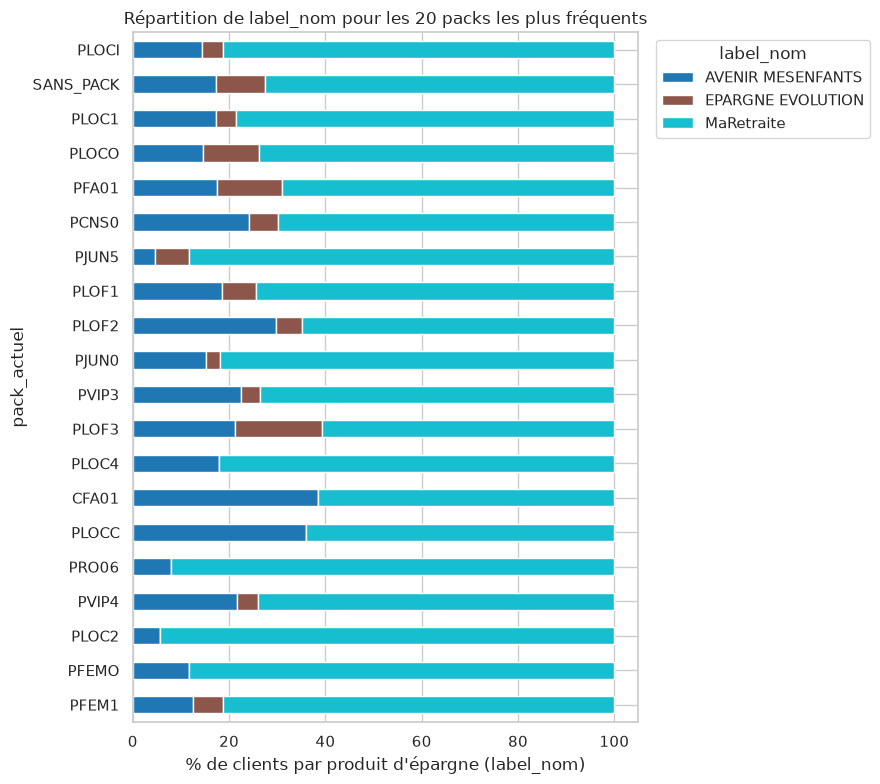

label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite
pack_actuel,,,
PLOCI,14.3,4.3,81.3
SANS_PACK,17.2,10.2,72.6
PLOC1,17.4,4.0,78.7
PLOCO,14.5,11.7,73.8
PFA01,17.5,13.5,69.0
PCNS0,24.1,6.2,69.7
PJUN5,4.7,7.1,88.2
PLOF1,18.6,7.1,74.4
PLOF2,29.7,5.4,64.9


In [24]:
df_pd = pd.read_csv("final.csv")

TOP_N_PACKS = 20
top_packs = df_pd["pack_actuel"].value_counts().head(TOP_N_PACKS).index

ct_pack = pd.crosstab(df_pd.loc[df_pd["pack_actuel"].isin(top_packs), "pack_actuel"],
                       df_pd["label_nom"], normalize="index") * 100
ct_pack = ct_pack.loc[top_packs]

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(ct_pack))))
ct_pack.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("% de clients par produit d'épargne (label_nom)")
ax.set_ylabel("pack_actuel")
ax.set_title(f"Répartition de label_nom pour les {TOP_N_PACKS} packs les plus fréquents")
ax.legend(title="label_nom", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

ct_pack.round(1)

In [35]:
df.filter(df["TAILLE_ENTREPRI"] == "99").count()

Series([], dtype: int64)

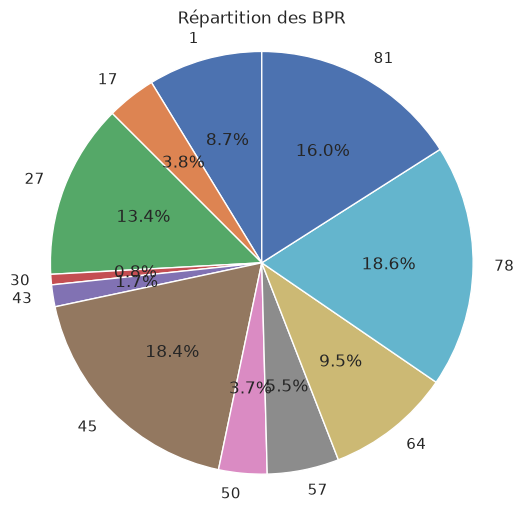

In [37]:
import matplotlib.pyplot as plt

counts = df.groupby("BPR").size()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des BPR")
plt.axis("equal")
plt.show()

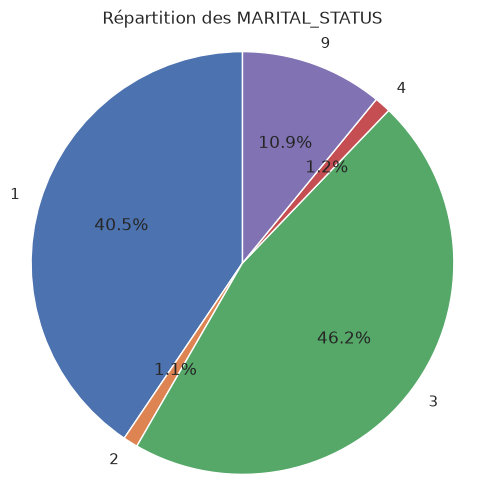

In [40]:
import matplotlib.pyplot as plt

counts = df.groupby("MARITAL_STATUS").size()

plt.figure(figsize=(6,6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des MARITAL_STATUS")
plt.axis("equal")
plt.show()

## 10. Synthèse

À compléter après lecture des graphiques ci-dessus, par exemple :
- Colonnes avec le plus de valeurs manquantes / cardinalité extrême
- Variables les plus discriminantes vis-à-vis de `label_nom`
- Paires de variables fortement corrélées à surveiller (colinéarité) pour la modélisation MLlib
- Déséquilibre de classes à traiter (pondération, sur/sous-échantillonnage, etc.)
